# Overview

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from importlib.util import find_spec
import skbio
skbio.__version__

'0.7.2'

In [2]:
#from skbio import Table
from skbio.diversity import alpha, beta_diversity
from skbio.stats.ordination import pcoa

In [3]:
# Import the data

otu = pd.read_csv("asv_table.tsv", sep="\t", index_col=0)

# look at the head of the table
otu.head()


,soil A,soil B,soil C,soil D,viable cells A,viable cells B,viable cells C,viable cells D,Live-FISH A,Live-FISH B,Live-FISH C,Live-FISH D
ASV1,66,70,35,52,28,32,15,19,31,24,38,32
ASV2,4045,3301,3437,3453,9025,8260,10216,9806,373,425,318,546
ASV3,112,110,84,121,1059,1163,1060,798,9029,10576,11768,4041
ASV4,2352,2990,2767,2647,912,924,455,2095,6043,5646,3172,9207
ASV5,35,27,48,66,2816,2275,2190,192,6188,5451,6171,346


In [4]:
#Calclate diversity, richness and eveness for the ASV matrix
observed_features = {}
shannon = {}
pielou = {}

for sample in otu:
    observed_features[sample] = alpha.sobs(otu[sample])
    shannon[sample] = alpha.shannon(otu[sample])
    pielou[sample] = alpha.pielou_e(otu[sample])

observed_features = pd.Series(observed_features)
shannon = pd.Series(shannon)
pielou = pd.Series(pielou)

observed_features

soil A            1993
soil B            2183
soil C            1784
soil D            1794
viable cells A    1597
viable cells B    1736
viable cells C    1613
viable cells D    1924
Live-FISH A       1569
Live-FISH B       1620
Live-FISH C       1591
Live-FISH D       1664
dtype: int64

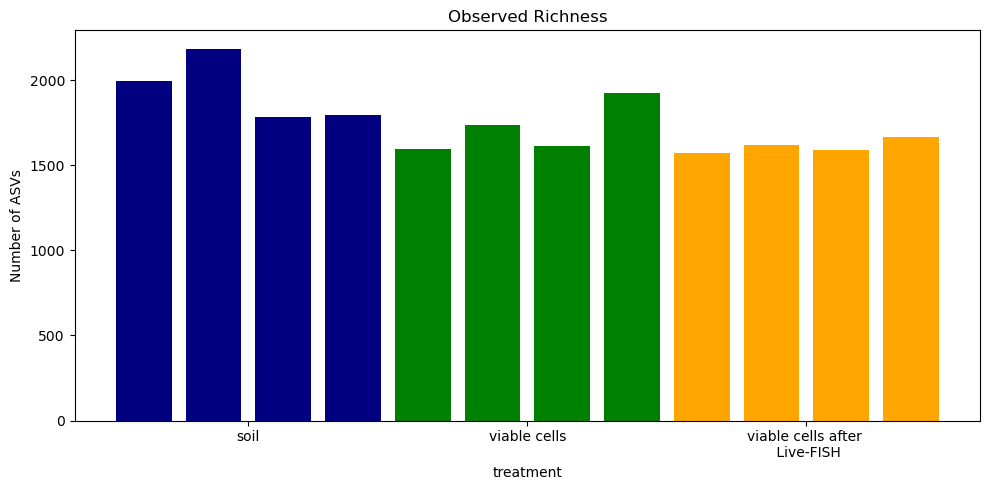

In [5]:
# Your data
values = observed_features.values
samples = observed_features.index

# Group into 3 groups of 4 samples each
group1 = values[0:4]
group2 = values[4:8]
group3 = values[8:12]

data = np.concatenate([group1, group2, group3])

# Colors for each bar (4 + 4 + 4)
colors = ["navy"]*4 + ["green"]*4 + ["orange"]*4

plt.figure(figsize=(10,5))

# Plot bars
plt.bar(range(len(data)), data, color=colors)

# Add group labels centred under each group of four bars
plt.xticks(
    [1.5, 5.5, 9.5],      # midpoints of each group of 4
    ["soil", "viable cells", "viable cells after \n Live-FISH"],
    rotation=0
)

plt.title("Observed Richness")
plt.ylabel("Number of ASVs")
plt.xlabel("treatment")

plt.tight_layout()
plt.show()

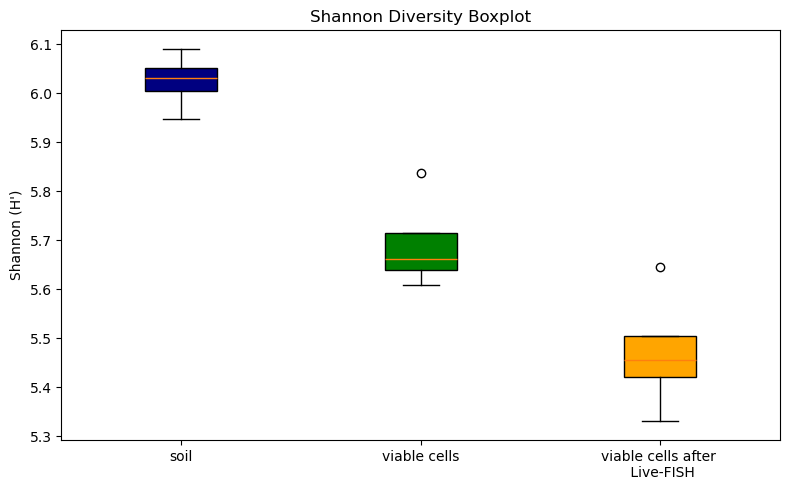

In [6]:
# Your data
values = shannon.values
samples = shannon.index

# Group into 3 groups of 4 samples each
group1 = values[0:4]
group2 = values[4:8]
group3 = values[8:12]

data = [group1, group2, group3]

colors = ["navy", "green", "orange"]

# Create a boxplot
plt.figure(figsize=(8,5))

bp = plt.boxplot(data, patch_artist=True)

# Color each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Labels for each group
plt.xticks([1,2,3], ["soil", "viable cells", "viable cells after \n Live-FISH"])

plt.title("Shannon Diversity Boxplot")
plt.ylabel("Shannon (H')")

plt.tight_layout()
plt.show()

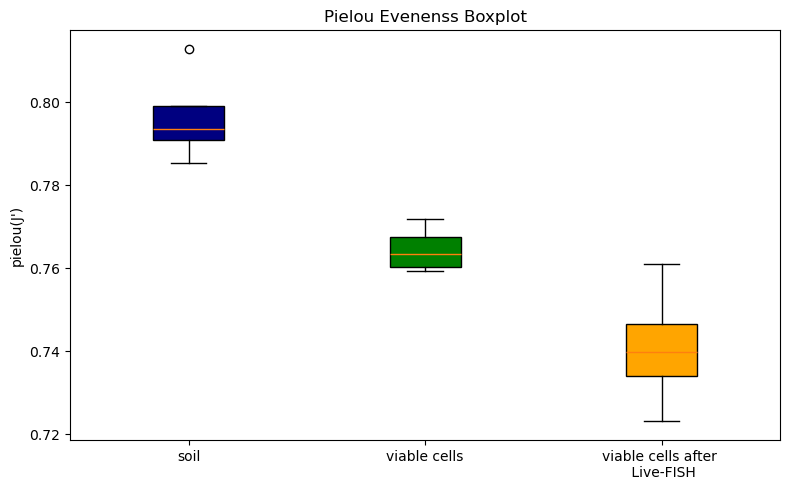

In [7]:
# Your data
values = pielou.values
samples = pielou.index

# Group into 3 groups of 4 samples each
group1 = values[0:4]
group2 = values[4:8]
group3 = values[8:12]

data = [group1, group2, group3]

colors = ["navy", "green", "orange"]

# Create a boxplot
plt.figure(figsize=(8,5))

bp = plt.boxplot(data, patch_artist=True)

# Color each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Labels for each group
plt.xticks([1,2,3], ["soil", "viable cells", "viable cells after \n Live-FISH"])

plt.title("Pielou Evenenss Boxplot")
plt.ylabel("pielou(J')")

plt.tight_layout()
plt.show()

In [13]:
# Suppose df = OTU table (rows = ASVs, cols = samples)
# Bray-Curtis distance

distanceMatrix = beta_diversity(metric="braycurtis", counts=otu)
distanceMatrix.data

dm = beta_diversity(
    metric="braycurtis",
    counts=otu.T.values,
    ids=otu.columns
)

# Run PCoA
ord1 = pcoa(dm)

# Look at results
ord1.samples.head()
ord1.proportion_explained

/Users/Meriel/miniconda3/envs/scikit-bio/lib/python3.14/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


PC1     0.578139
PC2     0.312829
PC3     0.055010
PC4     0.019941
PC5     0.007963
PC6     0.006273
PC7     0.005521
PC8     0.004746
PC9     0.004384
PC10    0.002935
PC11    0.002258
PC12    0.000000
dtype: float64

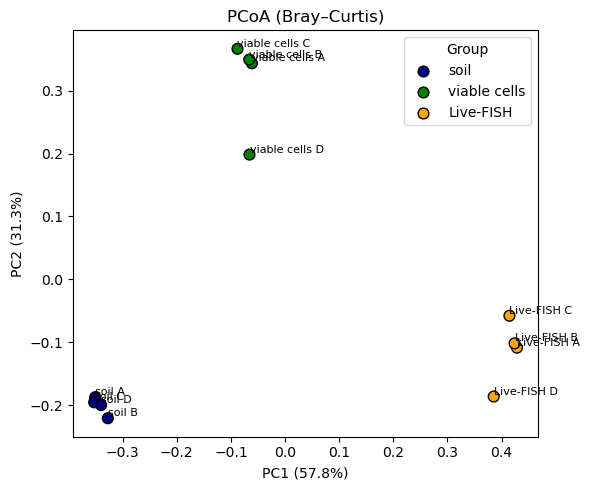

In [12]:
# ord1 is the result of pcoa(dm)
pc = ord1.samples  # rows = samples, columns = PC1, PC2, ...

# Choose the first two axes safely
pc1_label = pc.columns[0]  # usually "PC1"
pc2_label = pc.columns[1]  # usually "PC2"

# Get proportion explained safely (Series indexed by "PC1","PC2",...)
pe = ord1.proportion_explained
pc1_var = (pe.iloc[0] if pc1_label not in pe.index else pe[pc1_label]) * 100
pc2_var = (pe.iloc[1] if pc2_label not in pe.index else pe[pc2_label]) * 100

# ---- Color mapping based on name prefixes ----
# Match case-insensitively on the start of the sample name
def color_for(sample_name: str) -> str:
    s = str(sample_name).lower()
    if s.startswith("soil"):
        return "navy"
    if s.startswith("viable cells"):
        return "green"
    if s.startswith("live-fish") or s.startswith("live_fish") or s.startswith("live fish"):
        return "orange"
    return "gray"

colors = [color_for(s) for s in pc.index]

# For legend: map label -> color, only for those present
label_order = [("soil", "navy"), ("viable cells", "green"), ("Live-FISH", "orange")]
present = [(lab, col) for lab, col in label_order if col in colors]

plt.figure(figsize=(6,5))

# Scatter all points
plt.scatter(pc[pc1_label], pc[pc2_label], s=60, edgecolor="k", c=colors)

# Add sample labels
for sample in pc.index:
    plt.text(pc.loc[sample, pc1_label], pc.loc[sample, pc2_label],
             sample, fontsize=8, va="bottom")

# Make legend by plotting (invisible) proxy handles for present groups
for lab, col in present:
    plt.scatter([], [], c=col, edgecolor="k", s=60, label=lab)
plt.legend(frameon=True, title="Group", loc="best")

plt.xlabel(f"{pc1_label} ({pc1_var:.1f}%)")
plt.ylabel(f"{pc2_label} ({pc2_var:.1f}%)")
plt.title("PCoA (Bray–Curtis)")
plt.tight_layout()
plt.show()